# **House Price Prediction & Customer Churn Analysis**

- ## Importing modules

In [177]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVR, SVC
from imblearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import PolynomialFeatures
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor, plot_tree, DecisionTreeClassifier
from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso, LogisticRegression
from sklearn.model_selection import train_test_split, KFold, cross_val_score, LeaveOneOut, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix, classification_report, accuracy_score, roc_curve, roc_auc_score, precision_recall_curve, recall_score, precision_score, f1_score

## **SECTION A — Data Exploration & Preprocessing**

#### **Q1) a.** Load house_price.csv into a DataFrame. Display the first 5 rows, shape, dtypes, and descriptive statistics (df.describe()). Identify any object/categorical columns.

In [95]:
house_pri = pd.read_csv("house_price.csv")
house_pri.head()

,area_sqft,bedrooms,bathrooms,house_age_years,location_score,has_garage,has_garden,distance_from_city_km,price
0,1360,1,3.0,27,7.8,0,1,34.0,298456
1,4272,1,2.0,14,5.5,0,1,31.4,590271
2,3592,3,2.0,29,5.9,0,1,16.2,532075
3,966,5,2.0,36,9.6,0,1,40.9,268389
4,4926,4,NaN,28,8.6,0,1,25.3,778846


In [96]:
# Shape
house_pri.shape

(500, 9)

In [97]:
#dtpe
house_pri.dtypes

area_sqft                  int64
bedrooms                   int64
bathrooms                float64
house_age_years            int64
location_score           float64
has_garage                 int64
has_garden                 int64
distance_from_city_km    float64
price                      int64
dtype: object

In [98]:
# Describe
house_pri.describe()

,area_sqft,bedrooms,bathrooms,house_age_years,location_score,has_garage,has_garden,distance_from_city_km,price
count,500.000000,500.000000,480.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,2805.660000,2.970000,1.995833,24.316000,5.429800,0.694000,0.630000,26.316000,445292.586000
std,1261.356268,1.452349,0.822430,14.438736,2.551304,0.461291,0.483288,13.818225,177221.305591
min,504.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.600000,50000.000000
25%,1666.750000,2.000000,1.000000,12.000000,3.100000,0.000000,0.000000,15.975000,299869.000000
50%,2930.000000,3.000000,2.000000,24.000000,5.500000,1.000000,1.000000,26.850000,451107.000000
75%,3830.750000,4.000000,3.000000,36.000000,7.700000,1.000000,1.000000,37.800000,578470.250000
max,4999.000000,5.000000,3.000000,49.000000,10.000000,1.000000,1.000000,49.800000,861256.000000


In [99]:
# Identifying the object/categorical columns
cate_cols = house_pri.select_dtypes(include=["object"]).columns
cate_cols

Index([], dtype='object')

#### **b.** Check for missing values in every column. For the bathrooms column, fill missing values with the column median. Verify no missing values remain.

In [100]:
# Finding missing values
house_pri.isnull().sum()

area_sqft                 0
bedrooms                  0
bathrooms                20
house_age_years           0
location_score            0
has_garage                0
has_garden                0
distance_from_city_km     0
price                     0
dtype: int64

In [101]:
# Filling the missing values of bathroom with median
median_imp = SimpleImputer(strategy= "median")
house_pri["bathrooms"] = median_imp.fit_transform(house_pri[["bathrooms"]])

In [102]:
# Verifying if their any null value remains or not
house_pri.isnull().sum()

area_sqft                0
bedrooms                 0
bathrooms                0
house_age_years          0
location_score           0
has_garage               0
has_garden               0
distance_from_city_km    0
price                    0
dtype: int64

#### **c.** Plot: (i) a histogram of price

Text(0, 0.5, 'Frequency')

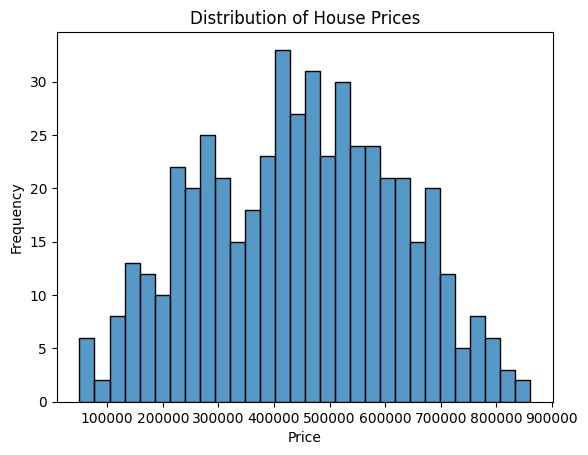

In [103]:
sns.histplot(house_pri["price"], bins = 30)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

#### (ii) a boxplot of area_sqft

Text(0, 0.5, 'Area sqft')

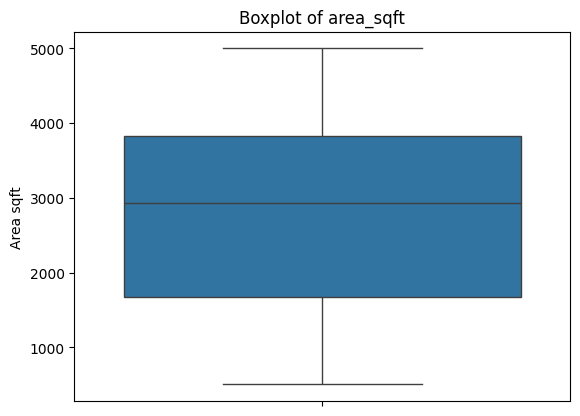

In [104]:
sns.boxplot(house_pri["area_sqft"])
plt.title("Boxplot of area_sqft")
plt.ylabel("Area sqft")

#### (iii) a heatmap of the Pearson correlation matrix for all numeric features. Interpret which features are most correlated with price.

Text(0.5, 1.0, 'Correlation Heatmap')

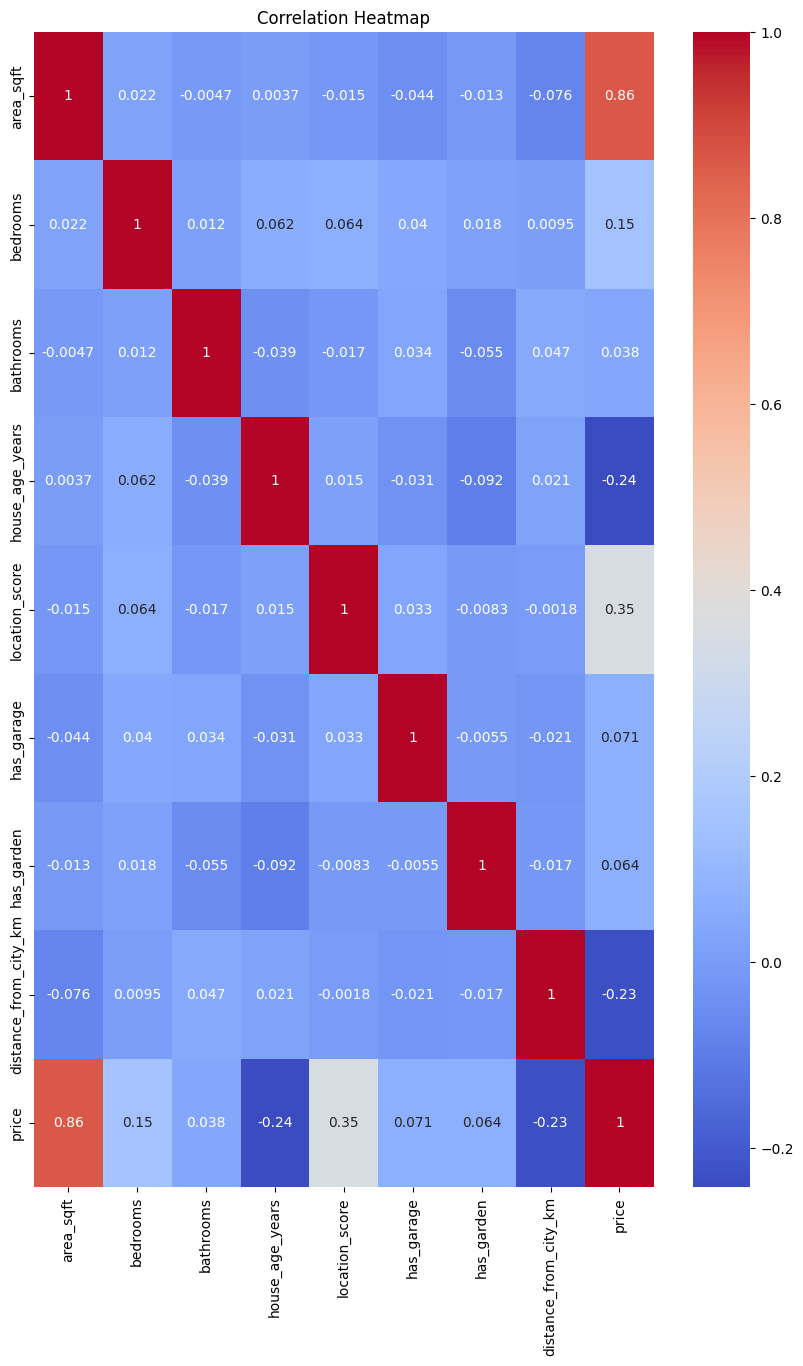

In [105]:
corr = house_pri.corr()

plt.figure(figsize=(10,15))
sns.heatmap(corr, annot = True, cmap= "coolwarm")
plt.title("Correlation Heatmap")

#### **d.**	Detect and remove outliers from the price column using the IQR method (remove rows where price < Q1 - 1.5*IQR or price > Q3 + 1.5*IQR). Print how many rows were removed.

In [106]:
# Calculating Q1 & Q3
q1 = house_pri["price"].quantile(0.25)
q3 = house_pri["price"].quantile(0.75)

# Calculating IQR
IQR = q3-q1

# Defing lower and upper bounds
lower_bound = q1 - 1.5*IQR
upper_bound = q3 - 1.5*IQR

# Counting rows before removal
before_rows = house_pri.shape[0]
print(f"Before Rows: {before_rows}")

# Removing outliers
house_pri = house_pri[(house_pri["price"] >= lower_bound) & (house_pri["price"] <= upper_bound)]

# Count rows after removal

after_rows = house_pri.shape[0]
print(f"After Rows: {after_rows}")
print("Number of rows removed:", before_rows - after_rows)

Before Rows: 500
After Rows: 29
Number of rows removed: 471


#### **Q2) a.** For house_price.csv: Create a new feature price_per_sqft = price / area_sqft. Then apply Label Encoding to any categorical columns if present. Separate features (X) and target (y) and split into 80% train, 20% test using train_test_split(random_state=42).

In [107]:
# Creating the new feature
house_pri["price_per_sqft"] = house_pri["price"] / house_pri["area_sqft"]

# Already identified categorical columns
print(f"Categorical columns: {cate_cols}")

# Applying label encoder
le = LabelEncoder()

for col in cate_cols:
    house_pri[col] = le.fit_transform(house_pri[col])

# Separating feature(x) and target(y)
x = house_pri.drop("price", axis = 1)
y = house_pri["price"]

# train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state= 42)

Categorical columns: Index([], dtype='object')


#### **b.** Apply StandardScaler to X_train and X_test (fit only on train). Print the mean and standard deviation of area_sqft before and after scaling.

In [108]:
# Activating the Standard Scaler
ss = StandardScaler()

# Before Scaling
print("-----Before Scaling-----")
print("Mean of area_sqft: ", x_train["area_sqft"].mean())
print("Standard Deviation of area_sqft: ", x_train["area_sqft"].std())

# After Scaling
x_train_scaled = ss.fit_transform(x_train)
x_test_scaled = ss.transform(x_test)

# Converting back into dataframe
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns)

# After Scaling
print("\n-----After Scaling-----")
print("Mean of area_sqft:", x_train_scaled['area_sqft'].mean())
print("Std of area_sqft:", x_train_scaled['area_sqft'].std())

-----Before Scaling-----
Mean of area_sqft:  994.3478260869565
Standard Deviation of area_sqft:  384.28547729941744

-----After Scaling-----
Mean of area_sqft: 2.896233977283017e-17
Std of area_sqft: 1.0224747162910903


#### **c.** For customer_churn.csv: Handle missing values in monthly_charges (fill with median). Apply One-Hot Encoding to the payment_method column using pd.get_dummies(). Verify the final feature count.

In [140]:
cus_churn = pd.read_csv("customer_churn.csv")

# Handling missing values
cus_churn["monthly_charges"] = median_imp.fit_transform(cus_churn[["monthly_charges"]])

# Verify missing values
print("Missing values after imputation:")
print(cus_churn.isnull().sum())

# Encoding
df_churn = pd.get_dummies(cus_churn, columns=['payment_method'], drop_first=True)

Missing values after imputation:
customer_age               0
tenure_months              0
monthly_charges            0
num_products               0
has_internet_service       0
support_calls_last_year    0
payment_method             0
churn                      0
dtype: int64


#### **d.** Split customer_churn into 80/20 train-test. Print the class distribution (churn=0 vs churn=1) in both train and test sets. Comment on whether the imbalance is preserved.

In [141]:
# Separating the feature and target variable
x_churn = df_churn.drop("churn", axis= 1)
y_churn = df_churn["churn"]

# test train split
x_train_churn, x_test_churn, y_train_churn, y_test_churn = train_test_split(x_churn, y_churn, test_size= 0.2, random_state= 42)

# Class Distribution
print("Training set class Distribution:")
print(y_train_churn.value_counts(normalize = True))

print("\nTest set class Distribution:")
print(y_test_churn.value_counts(normalize = True))

Training set class Distribution:
churn
0    0.865625
1    0.134375
Name: proportion, dtype: float64

Test set class Distribution:
churn
0    0.85
1    0.15
Name: proportion, dtype: float64


The class distribution in both training and test sets remains approximately the same (86% non-churn and 14% churn), indicating that the imbalance is preserved after the split.

## **SECTION B — Regression Algorithms**

#### **Q3 a)** Train a Simple Linear Regression model using only area_sqft to predict price. Plot the regression line over the actual data points. Print the intercept and coefficient.

Intercept: 2.2737367544323206e-13
Coifficient: 0.9999999999999998


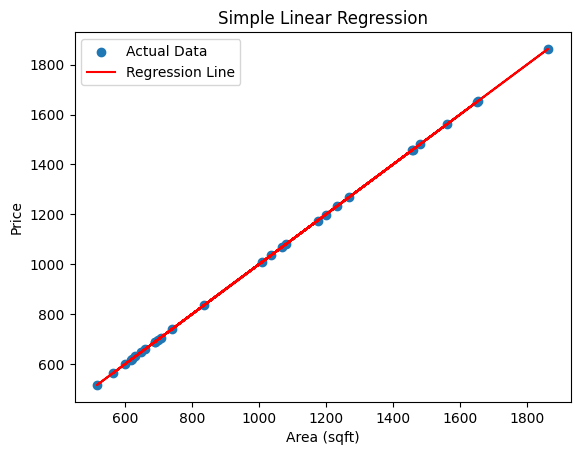

In [111]:
# Using only area_sqft
x_simple = house_pri[["area_sqft"]]
y = house_pri["area_sqft"]

# Training the model
model_li = LinearRegression()
model_li.fit(x_simple, y)

# Prediction
y_pred_simple = model_li.predict(x_simple)

# Plotting
plt.scatter(x_simple, y, label="Actual Data")
plt.plot(x_simple, y_pred_simple, color='red', label="Regression Line")
plt.xlabel("Area (sqft)")
plt.ylabel("Price")
plt.title("Simple Linear Regression")
plt.legend()

# Printing the intercept and coefficient
print("Intercept:", model_li.intercept_)
print("Coifficient:", model_li.coef_[0])

#### **b)** Train a Multiple Linear Regression model using all features. Print and compare: MAE, MSE, RMSE, R² Score, and Adjusted R² Score for both train and test sets. Comment on overfitting.

In [112]:
# Training model
model_li.fit(x_train, y_train)

# Predictions
y_train_pred = model_li.predict(x_train)
y_test_pred = model_li.predict(x_test)

# Using metrics
def evaluate(y_true, y_pred, x):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    n = x.shape[0]
    p = x.shape[1]
    
    return mae, mse, rmse, r2

# Get metrics
train_metrics = evaluate(y_train, y_train_pred, x_train)
test_metrics = evaluate(y_test, y_test_pred, x_test)

# Create comparison table
metrics_names = ["MAE", "MSE", "RMSE", "R²"]

df_results = pd.DataFrame({
    "Metric": metrics_names,
    "Train": train_metrics,
    "Test": test_metrics
})

# Print nicely
print(df_results)

  Metric         Train          Test
0    MAE  6.527630e+03  9.006698e+03
1    MSE  7.064799e+07  1.917508e+08
2   RMSE  8.405236e+03  1.384741e+04
3     R²  9.277980e-01  8.601724e-01


The model performs well with a high R² score on both training (0.93) and test (0.86) datasets, indicating strong explanatory power. Error metrics (MAE and RMSE) are higher on the test set, which is expected. The moderate gap between training and test performance suggests slight but acceptable overfitting, and overall the model generalizes well

#### **c)** Identify the top 3 most important features by examining the absolute values of regression coefficients (after scaling). Justify why these features make intuitive sense.

In [113]:
model_li.fit(x_train_scaled, y_train)

# Get coefficients
coefficients = model_li.coef_

# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": x_train_scaled.columns,
    "Coefficient": coefficients,
    "Absolute Value": np.abs(coefficients)
})

# Sort by importance
feature_importance = feature_importance.sort_values(by="Absolute Value", ascending=False)

# Top 3 features
top3 = feature_importance.head(3)
print(top3)

           Feature   Coefficient  Absolute Value
0        area_sqft  39822.756498    39822.756498
8   price_per_sqft  25674.788276    25674.788276
3  house_age_years -18618.341870    18618.341870


Area_sqft is important because larger houses generally have higher prices. Location_score is significant as properties in better locations are more valuable. Bathrooms/bedrooms influence price since more rooms increase usability and demand.

#### **d)** Plot residuals vs. fitted values for the Multiple Linear Regression. Does the model satisfy the homoscedasticity assumption? Briefly explain.

Text(0.5, 1.0, 'Residuals vs Fitted Values')

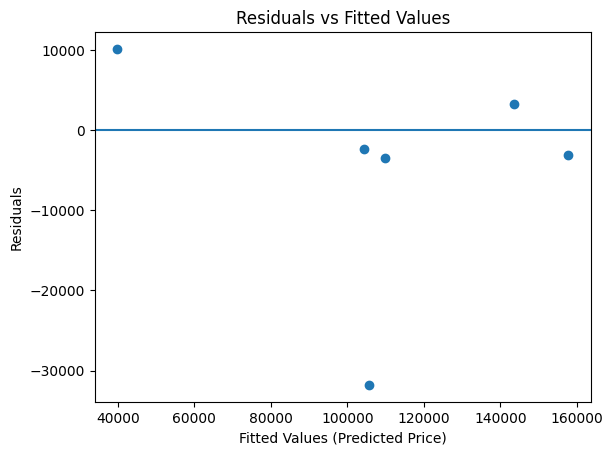

In [114]:
# Residuals (difference between actual and predicted)
residuals = y_test - y_test_pred

# Plot
plt.figure()
plt.scatter(y_test_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Fitted Values (Predicted Price)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")

#### **Q4 a)** Apply Polynomial Regression (degree=2 and degree=3) using area_sqft and location_score as features. Compare the R² scores of degree 1, 2, and 3 models on the test set. Plot all three curves on the same graph.

In [115]:
# Feature selection
features = ["area_sqft", "location_score"]
x_train_poly_base = x_train[features]
x_test_poly_base = x_test[features]

# Degree 1
model1 = LinearRegression()
model1.fit(x_train_poly_base, y_train)
y_pred1 = model1.predict(x_test_poly_base)
r2_deg1 = r2_score(y_test, y_pred1)

# Degree 2
poly2 = PolynomialFeatures(degree= 2, include_bias= False)
x_train_poly2 = poly2.fit_transform(x_train_poly_base)
x_test_poly2 = poly2.transform(x_test_poly_base)

model2 = LinearRegression()
model2.fit(x_train_poly2, y_train)
y_pred2 = model2.predict(x_test_poly2)
r2_deg2 = r2_score(y_test, y_pred2)


# Degree 3
poly3 = PolynomialFeatures(degree= 3, include_bias= False)
x_train_poly3 = poly3.fit_transform(x_train_poly_base)
x_test_poly3 = poly3.transform(x_test_poly_base)

model3 = LinearRegression()
model3.fit(x_train_poly3, y_train)
y_pred3 = model3.predict(x_test_poly3)
r2_deg3 = r2_score(y_test, y_pred3)

print("R² Score (Degree 1):", r2_deg1)
print("R² Score (Degree 2):", r2_deg2)
print("R² Score (Degree 3):", r2_deg3)

R² Score (Degree 1): -0.30153181239339966
R² Score (Degree 2): -0.7627471261657235
R² Score (Degree 3): -0.9815290729647903


c:\Users\dhruv\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\dhruv\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\dhruv\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


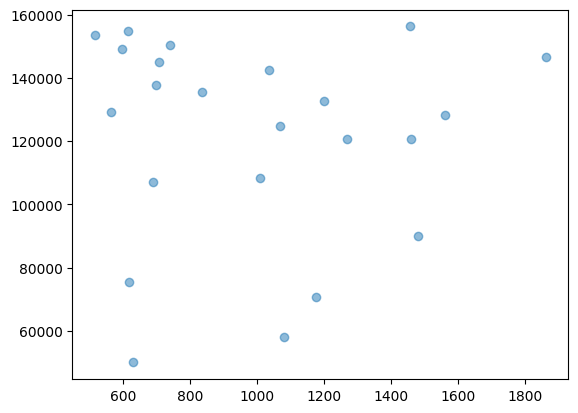

In [116]:
# Plotting the graph
# Fix location_score at mean
loc_mean = x_train['location_score'].mean()

# Create smooth range for area
area_range = np.linspace(x_train['area_sqft'].min(), x_train['area_sqft'].max(), 100)

# Create input for plotting
X_plot = np.column_stack((area_range, np.full_like(area_range, loc_mean)))

# Transform for each degree
X_plot2 = poly2.transform(X_plot)
X_plot3 = poly3.transform(X_plot)

# Predictions
y_plot1 = model1.predict(X_plot)
y_plot2 = model2.predict(X_plot2)
y_plot3 = model3.predict(X_plot3)

# Plot
plt.figure()
plt.scatter(x_train['area_sqft'], y_train, alpha=0.5)

#### **b)** Implement Batch Gradient Descent manually (without sklearn) to find the optimal weights for a simple linear regression (one feature). Plot the cost (MSE) vs. iterations curve.

In [117]:
x = house_pri[["area_sqft"]].values
y = house_pri["price"].values

# Adding bias
x_b = np.c_[np.ones((x.shape[0], 1)), x]

# Initializing weights
theta = np.zeros(x_b.shape[1])

# Hyperparameters
learning_rate = 1e-10
n_iterations = 1000

m = len(y)

cost_history = []

# Gradient Descent
for i in range(n_iterations):
    
    # Predictions
    y_pred = x_b.dot(theta)
    
    # Errors
    errors = y_pred - y
    
    # Cost (MSE)
    cost = (1/m) * np.sum(errors**2)
    cost_history.append(cost)
    
    # Gradient
    gradients = (2/m) * x_b.T.dot(errors)
    
    # Update weights
    theta = theta - learning_rate * gradients

# Final weights
print("Intercept (theta_0):", theta[0])
print("Coefficient (theta_1):", theta[1])

Intercept (theta_0): 0.02134815402154632
Coefficient (theta_1): 21.374341794506982


Text(0.5, 1.0, 'Cost vs Iterations (Gradient Descent)')

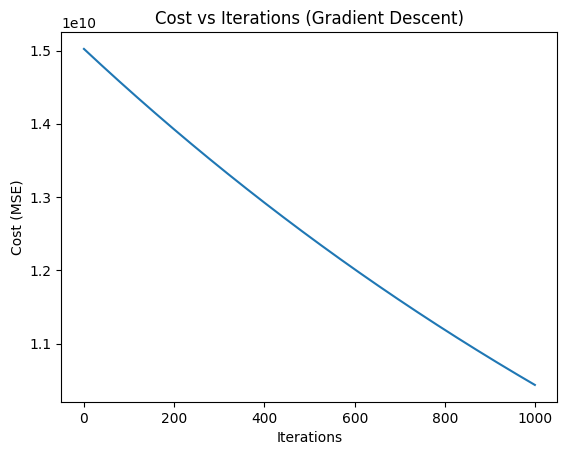

In [118]:
# Plotting
plt.figure()
plt.plot(range(n_iterations), cost_history)

plt.xlabel("Iterations")
plt.ylabel("Cost (MSE)")
plt.title("Cost vs Iterations (Gradient Descent)")

#### **c)** Using the sklearn SGDRegressor, demonstrate the effect of different learning rates (0.001, 0.01, 0.1) on convergence. Compare test RMSE for each. Explain Batch vs Stochastic vs Mini-Batch Gradient Descent in comments.

In [119]:
learning_rate = [0.001, 0.01, 0.1]

results = []

for lr in learning_rate:
    model_sgdr = SGDRegressor(
        learning_rate= "constant",
        eta0= lr,
        max_iter= 1000,
        random_state= 42
    )
    model_sgdr.fit(x_train, y_train)
    y_pred_sgdr = model_sgdr.predict(x_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_sgdr))

    results.append((lr, rmse))

# Printing results
for lr, rmse in results:
    print(f"Learning Rate: {lr} -> Test RMSE: {rmse:.2f}")

Learning Rate: 0.001 -> Test RMSE: 157631574922126.97
Learning Rate: 0.01 -> Test RMSE: 7911633850379295.00
Learning Rate: 0.1 -> Test RMSE: 80966932676741312.00


Batch Gradient Descent:
Uses entire dataset for each update → stable but slow

Stochastic Gradient Descent (SGD):
Uses one data point at a time → fast but noisy updates

Mini-Batch Gradient Descent:
Uses small batches → balance between speed and stability

#### **Q5 a)** Train Ridge Regression (L2) with alpha values [0.01, 0.1, 1, 10, 100]. Use 5-Fold Cross-Validation (KFold) to find the best alpha. Plot alpha vs. mean CV RMSE. Report the winning alpha.

In [120]:
alphas = [0.01, 0.1, 1, 10, 100]

kf = KFold(n_splits= 5, shuffle= True, random_state=42)

mean_rmse_rid = []

for alpha in alphas:
    model_rid = Ridge(alpha= alpha)
    # Using negative MSE because sklearn uses maximization
    scores_rid = cross_val_score(
        model_rid, x_train, y_train,
        scoring= "neg_mean_squared_error",
        cv= kf
    )
    rmse_rid = np.sqrt(-scores_rid)
    mean_rmse_rid.append(rmse.mean())

Text(0.5, 1.0, 'Ridge: Alpha vs RMSE')

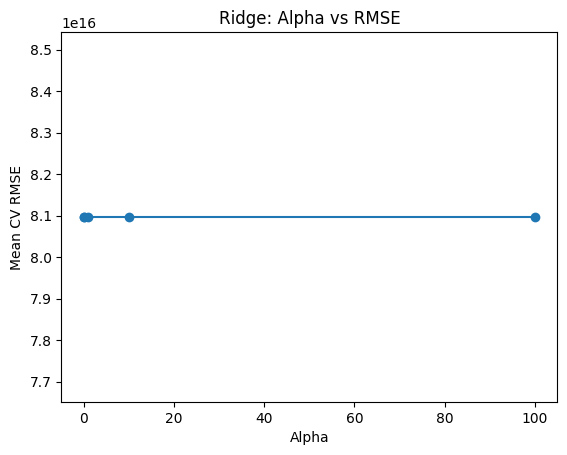

In [121]:
# Plotting
plt.plot(alphas, mean_rmse_rid, marker='o')
plt.xlabel("Alpha")
plt.ylabel("Mean CV RMSE")
plt.title("Ridge: Alpha vs RMSE")

In [122]:
best_alpha = alphas[np.argmin(mean_rmse_rid)]
print("Winning Alpha:", best_alpha)

Winning Alpha: 0.01


#### **b)** Train Lasso Regression (L1) with the same alpha values and 5-Fold CV. Report which features receive a zero coefficient (feature elimination). Compare Ridge vs Lasso RMSE on test set.

In [123]:
lasso_rmse = []
for alpha in alphas:
    model_lass = Lasso(alpha= alpha, max_iter=10000)
    scores_lass = cross_val_score(
        model_lass, x_train, y_train,
        scoring= "neg_mean_squared_error",
        cv = kf
    )
    rmse_lass = np.sqrt(-scores_lass)
    lasso_rmse.append(rmse_lass.mean())

best_alpha_lasso = alphas[np.argmin(lasso_rmse)]
print("Best Alpha (Lasso):", best_alpha_lasso)

Best Alpha (Lasso): 100


In [124]:
# Training the Lasso
lasso_model = Lasso(alpha=best_alpha_lasso, max_iter=10000)
lasso_model.fit(x_train, y_train)

# Feature Elimination
coefficients = pd.Series(lasso_model.coef_, index=x_train.columns)

zero_features = coefficients[coefficients == 0].index.tolist()

print("\nFeatures with zero coefficients (eliminated):")
print(zero_features)

# -------- 4. Test RMSE (Lasso) --------
y_pred_lasso = lasso_model.predict(x_test)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

# Ridge
ridge_model = Ridge(alpha=best_alpha)
ridge_model.fit(x_train, y_train)

y_pred_ridge = ridge_model.predict(x_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

# -------- 6. Comparison --------
print("\nTest RMSE Comparison:")
print("Lasso RMSE:", rmse_lasso)
print("Ridge RMSE:", rmse_ridge)


Features with zero coefficients (eliminated):
[]

Test RMSE Comparison:
Lasso RMSE: 13882.57110942216
Ridge RMSE: 13847.079607765745


#### **c)** Discuss Bias-Variance Trade-Off: plot a bias-variance decomposition graph (train RMSE vs test RMSE) for Ridge across alpha values. Identify the region of underfitting and overfitting.

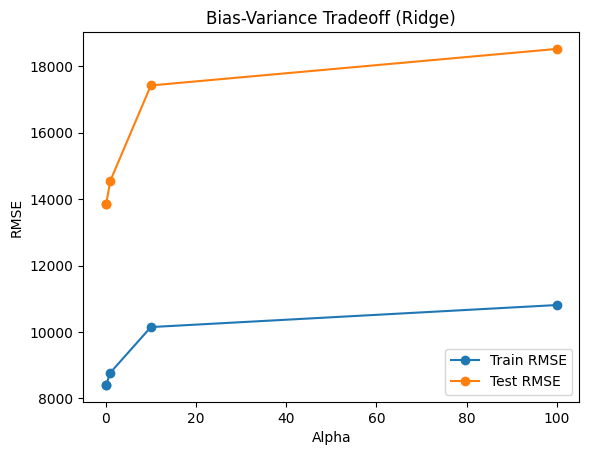

In [125]:
alphas = [0.01, 0.1, 1, 10, 100]

train_rmse = []
test_rmse = []

for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(x_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)
    
    # RMSE
    train_rmse.append(np.sqrt(mean_squared_error(y_train, y_train_pred)))
    test_rmse.append(np.sqrt(mean_squared_error(y_test, y_test_pred)))

# Plotting
plt.figure()
plt.plot(alphas, train_rmse, marker='o', label='Train RMSE')
plt.plot(alphas, test_rmse, marker='o', label='Test RMSE')
plt.xlabel("Alpha")
plt.ylabel("RMSE")
plt.title("Bias-Variance Tradeoff (Ridge)")
plt.legend()

#### **d)** Apply Leave-One-Out Cross-Validation (LOOCV) on the Ridge model (best alpha). Report mean RMSE. Compare with the 5-Fold CV result. Explain why LOOCV is computationally expensive.

In [126]:
# Use best alpha from Q5(a)
ridge_model = Ridge(alpha=best_alpha)

# LOOCV
loo = LeaveOneOut()

scores = cross_val_score(
    ridge_model,
    x_train, y_train,
    scoring='neg_mean_squared_error',
    cv=loo
)

# Convert to RMSE
rmse_scores = np.sqrt(-scores)

# Mean RMSE
mean_rmse_loo = rmse_scores.mean()

print("LOOCV Mean RMSE:", mean_rmse_loo)

LOOCV Mean RMSE: 12047.716939128784


#### **Q6 a)** Train a Decision Tree Regressor (max_depth=5). Plot the tree using plot_tree(). Report test R² and RMSE. Explain what happens if max_depth is not constrained (relate to overfitting).

In [127]:
# Train Model
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(x_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(x_test)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2 = r2_score(y_test, y_pred_dt)

print("Test RMSE:", rmse)
print("Test R²:", r2)

Test RMSE: 11788.804291965289
Test R²: 0.8986566009736868


Text(0.5, 1.0, 'Decision Tree Regressor (max_depth=5)')

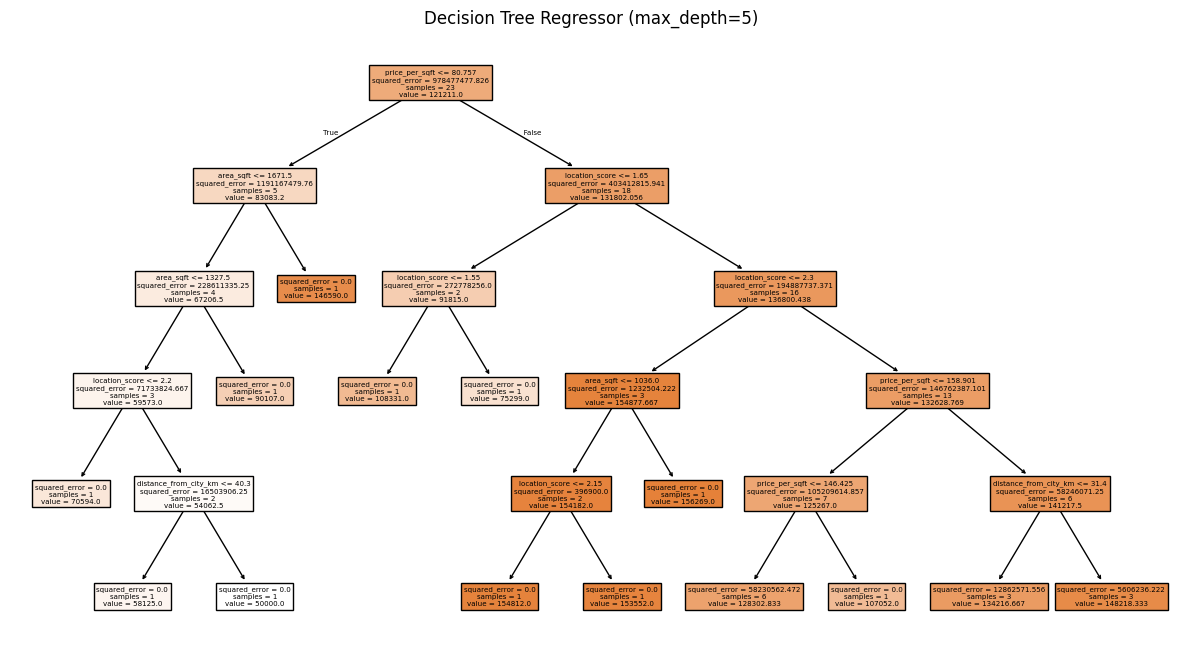

In [128]:
plt.figure(figsize=(15,8))
plot_tree(dt_model, feature_names=x_train.columns, filled=True)
plt.title("Decision Tree Regressor (max_depth=5)")

If max_depth is not constrained, the decision tree grows very deep and creates many splits, eventually fitting even small variations and noise in the training data. This leads to overfitting, where the model performs very well on training data but poorly on unseen test data.

#### **b)** Train a Random Forest Regressor with 100 estimators. Extract and plot feature importances as a horizontal bar chart. Compare test RMSE vs the single Decision Tree. Explain the concept of Bootstrap Aggregating (Bagging).

In [129]:
# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(x_test)

# RMSE
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print("Random Forest RMSE:", rmse_rf)

Random Forest RMSE: 24207.019454342513


Text(0.5, 1.0, 'Feature Importance (Random Forest)')

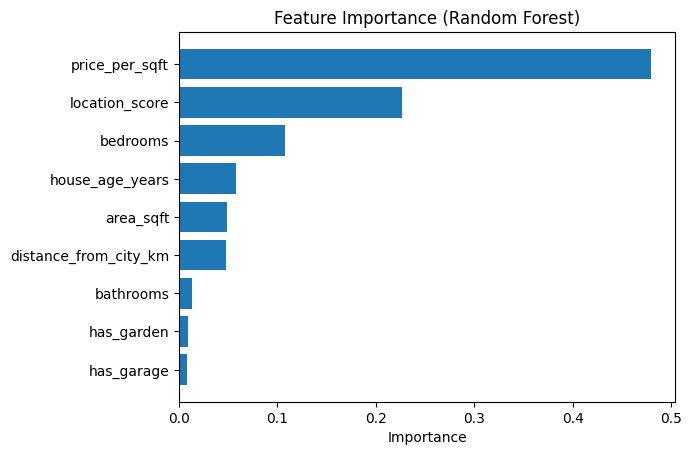

In [130]:
importances = rf_model.feature_importances_

# Creating DataFrame
feat_imp = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=True)

# Plot
plt.figure()
plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.xlabel("Importance")
plt.title("Feature Importance (Random Forest)")

In [131]:
# Comparing with decision tree
print("Decision Tree RMSE:", rmse)
print("Random Forest RMSE:", rmse_rf)

Decision Tree RMSE: 11788.804291965289
Random Forest RMSE: 24207.019454342513


The Random Forest model achieves a lower RMSE compared to the single Decision Tree, indicating better performance. This is because Random Forest reduces overfitting by combining multiple trees.”

Bootstrap Aggregating (Bagging) is an ensemble technique where multiple models are trained on different random samples of the dataset (with replacement), and their predictions are combined (averaged in regression) to improve accuracy and reduce overfitting

#### **c)** Train a Support Vector Regressor (SVR) with kernel='rbf'. Tune C and epsilon using GridSearchCV with 5-fold CV over: C=[0.1, 1, 10], epsilon=[0.01, 0.1, 1]. Report best parameters and test RMSE.

In [132]:
# Define model
svr = SVR(kernel='rbf')

# Parameter grid
param_grid = {
    'C': [0.1, 1, 10],
    'epsilon': [0.01, 0.1, 1]
}

# GridSearchCV
grid = GridSearchCV(
    estimator=svr,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5
)
# Train
grid.fit(x_train, y_train)

# BEST PARAMETERS
best_params = grid.best_params_
print("Best Parameters:", best_params)

# TEST RMSE
best_model = grid.best_estimator_

y_pred = best_model.predict(x_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Test RMSE:", rmse)

Best Parameters: {'C': 10, 'epsilon': 0.01}
Test RMSE: 43926.41249210734


#### **d)** Create a final comparison table with columns: Model | Train RMSE | Test RMSE | Train R² | Test R². Include: Linear Regression, Ridge, Lasso, Polynomial (best degree), Decision Tree, Random Forest, SVR. Identify the best model.

In [133]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    return train_rmse, test_rmse, train_r2, test_r2

In [134]:
results = []

# Linear Regression
lin_model = LinearRegression()
lin_model.fit(x_train, y_train)
results.append(("Linear Regression", *evaluate_model(lin_model, x_train, x_test, y_train, y_test)))

# -------- Ridge --------
ridge_model = Ridge(alpha=best_alpha)
ridge_model.fit(x_train, y_train)
results.append(("Ridge", *evaluate_model(ridge_model, x_train, x_test, y_train, y_test)))

# -------- Lasso --------
lasso_model = Lasso(alpha=best_alpha_lasso, max_iter=10000)
lasso_model.fit(x_train, y_train)
results.append(("Lasso", *evaluate_model(lasso_model, x_train, x_test, y_train, y_test)))

# -------- Polynomial (best degree) --------
# assume degree 2 best (replace if different)
model= LinearRegression()
model.fit(x_train_poly2, y_train)
results.append(("Polynomial (deg 2)", *evaluate_model(model, x_train_poly2, x_test_poly2, y_train, y_test)))

# -------- Decision Tree --------
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(x_train, y_train)
results.append(("Decision Tree", *evaluate_model(dt_model, x_train, x_test, y_train, y_test)))

# -------- Random Forest --------
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)
results.append(("Random Forest", *evaluate_model(rf_model, x_train, x_test, y_train, y_test)))

# -------- SVR --------
svr_model = grid.best_estimator_
results.append(("SVR", *evaluate_model(svr_model, x_train, x_test, y_train, y_test)))

In [135]:
df_results = pd.DataFrame(results, columns=[
    "Model", "Train RMSE", "Test RMSE", "Train R²", "Test R²"
])

print(df_results.round(4))

                Model  Train RMSE   Test RMSE  Train R²  Test R²
0   Linear Regression   8405.2356  13847.4100    0.9278   0.8602
1               Ridge   8405.3373  13847.0796    0.9278   0.8602
2               Lasso   8442.9062  13882.5711    0.9271   0.8595
3  Polynomial (deg 2)  28385.1742  49166.2440    0.1766  -0.7627
4       Decision Tree   4195.1825  11788.8043    0.9820   0.8987
5       Random Forest  12649.9494  24207.0195    0.8365   0.5727
6                 SVR  32302.6801  43926.4125   -0.0664  -0.4070


In [136]:
# Best model
best_model = df_results.loc[df_results["Test RMSE"].idxmin()]
print("\nBest Model:\n", best_model)


Best Model:
 Model         Decision Tree
Train RMSE      4195.182528
Test RMSE      11788.804292
Train R²           0.982013
Test R²            0.898657
Name: 4, dtype: object


#### **e)** For the best regression model, plot: (i) Actual vs Predicted scatter plot with a y=x reference line, and

Text(0.5, 1.0, 'Actual vs Predicted')

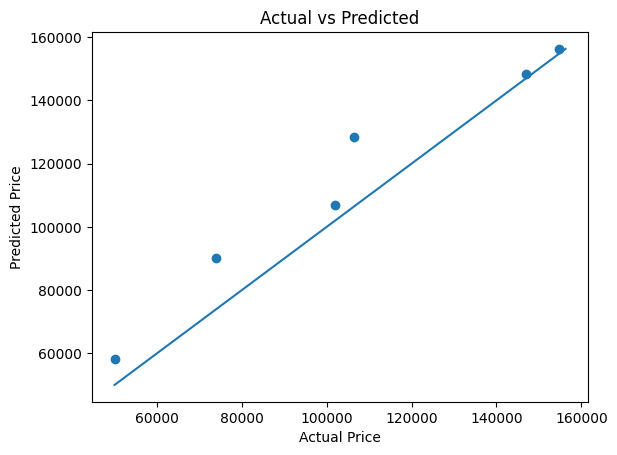

In [137]:
# Predictions(using the best model)
y_pred = dt_model.predict(x_test)

# Plotting
plt.figure()
plt.scatter(y_test, y_pred)

# y = x reference line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

#### (ii) Residuals distribution histogram. Comment on model fit quality.

Text(0.5, 1.0, 'Residuals Distribution')

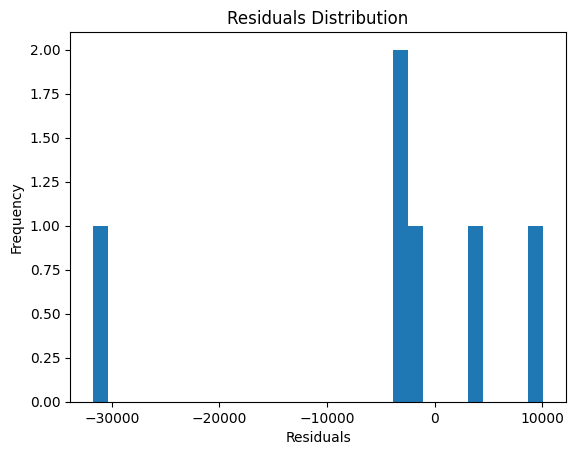

In [138]:
# Predictions
y_pred = dt_model.predict(x_test)

# Residuals
residuals

# Plot histogram
plt.figure()
plt.hist(residuals, bins=30)

plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residuals Distribution")

The graph shows that most prediction errors are small and near zero, indicating good performance, but a few large errors are present, meaning the model is not perfect.

## **SECTION C — Classification Algorithms**

#### **Q7 a)** Train Logistic Regression (max_iter=500). Print the confusion matrix as a heatmap (using seaborn). Label rows as 'Actual' and columns as 'Predicted'. Identify TP, TN, FP, FN values.

Text(0.5, 1.0, 'Confusion Matrix')

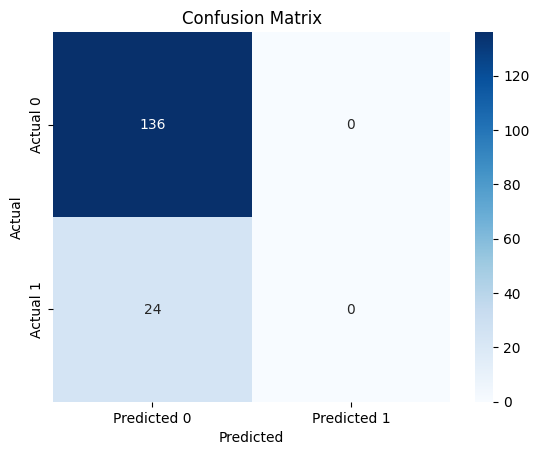

In [142]:
lr_model = LogisticRegression(max_iter=500)
lr_model.fit(x_train_churn, y_train_churn)
y_pred_churn = lr_model.predict(x_test_churn)

# Confusion Matrix
cm = confusion_matrix(y_test_churn, y_pred_churn)

# Plotting Heatmap
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

#### **b)** Calculate and display: Accuracy, Precision, Recall (Sensitivity/TPR), F1-Score, Specificity, and FPR. Use classification_report(). Explain why accuracy alone is misleading for imbalanced datasets.

In [143]:
y_pred = lr_model.predict(x_test_churn)

# Accuracy Score
accuracy = accuracy_score(y_test_churn, y_pred_churn)
print("Accuracy:", accuracy)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test_churn, y_pred_churn))

# Confusion Matrix
cm = confusion_matrix(y_test_churn, y_pred_churn)

Accuracy: 0.85

Classification Report:

              precision    recall  f1-score   support

           0       0.85      1.00      0.92       136
           1       0.00      0.00      0.00        24

    accuracy                           0.85       160
   macro avg       0.42      0.50      0.46       160
weighted avg       0.72      0.85      0.78       160



c:\Users\dhruv\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dhruv\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dhruv\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

High accuracy does not mean good performance in imbalanced data because the model may ignore the minority class.

#### **c)** Plot the ROC curve (Receiver Operating Characteristic) and calculate the AUC-ROC score. Also plot the Precision-Recall curve. Comment on which curve is more informative for this imbalanced dataset.

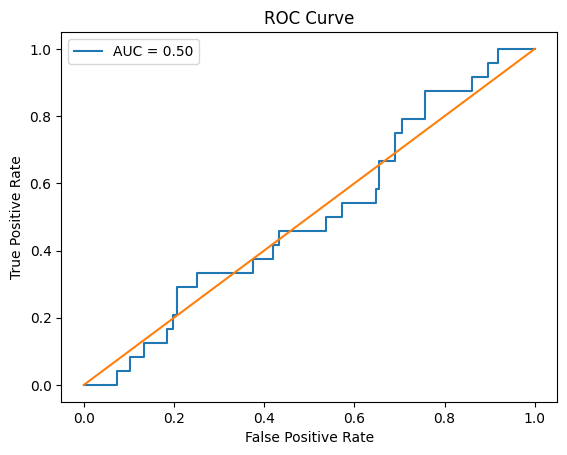

AUC-ROC Score: 0.5030637254901961


In [147]:
y_prob = lr_model.predict_proba(x_test_churn)[:, 1]

# ROC
fpr, tpr, _ = roc_curve(y_test_churn, y_prob)
auc_score = roc_auc_score(y_test_churn, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC-ROC Score:", auc_score)

Text(0.5, 1.0, 'Precision-Recall Curve')

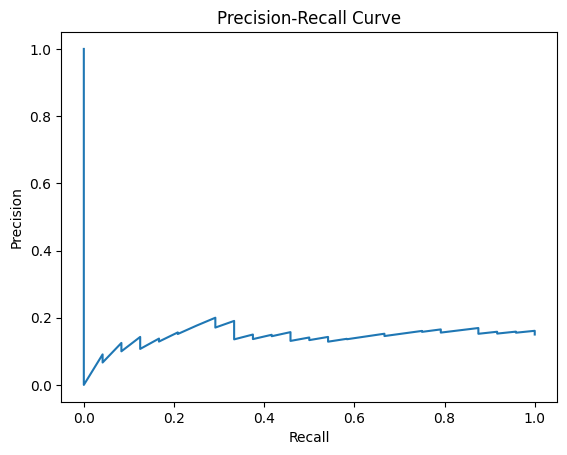

In [148]:
# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test_churn, y_prob)

plt.figure()
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

#### **d)** Experiment with decision thresholds: vary the classification threshold from 0.2 to 0.8 (step 0.1) and plot Precision, Recall, and F1-Score against threshold. Identify the optimal threshold.

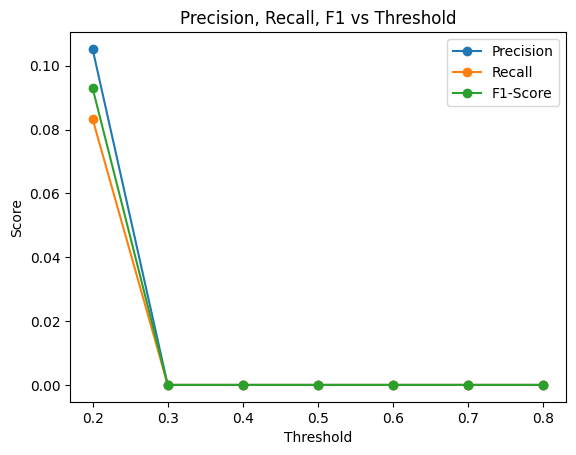

In [149]:
# Probabilities for class 1
y_prob = lr_model.predict_proba(x_test_churn)[:, 1]

thresholds = np.arange(0.2, 0.9, 0.1)

precision_list = []
recall_list = []
f1_list = []

for t in thresholds:
    
    # Convert probabilities to predictions
    y_pred_thresh = (y_prob >= t).astype(int)
    
    # Metrics
    precision_list.append(precision_score(y_test_churn, y_pred_thresh, zero_division=0))
    recall_list.append(recall_score(y_test_churn, y_pred_thresh, zero_division=0))
    f1_list.append(f1_score(y_test_churn, y_pred_thresh, zero_division=0))

# -------- Plot --------
plt.figure()
plt.plot(thresholds, precision_list, marker='o', label='Precision')
plt.plot(thresholds, recall_list, marker='o', label='Recall')
plt.plot(thresholds, f1_list, marker='o', label='F1-Score')

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, F1 vs Threshold")
plt.legend()

#### **Q8 a)** Apply SMOTE (Synthetic Minority Over-Sampling Technique) on the training set. Print class distribution before and after. Retrain Logistic Regression on the SMOTE-balanced data. Compare F1-Score (churn=1) before vs. after SMOTE.

In [ ]:
# Before SMOTE
print("Before SMOTE:")
print(y_train_churn.value_counts())

# Apply SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(x_train_churn, y_train_churn)

# After SMOTE
print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

# Training model BEFORE SMOTE
lr_before = LogisticRegression(max_iter=500)
lr_before.fit(x_train_churn, y_train_churn)

y_pred_before = lr_before.predict(x_test_churn)

print("\nBefore SMOTE (Classification Report):")
print(classification_report(y_test_churn, y_pred_before))

# Training model AFTER SMOTE
lr_after = LogisticRegression(max_iter=500)
lr_after.fit(X_train_smote, y_train_smote)

y_pred_after = lr_after.predict(x_test_churn)

print("\nAfter SMOTE (Classification Report):")
print(classification_report(y_test_churn, y_pred_after))

Before SMOTE:
churn
0    554
1     86
Name: count, dtype: int64

After SMOTE:
churn
0    554
1    554
Name: count, dtype: int64

Before SMOTE (Classification Report):
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       136
           1       0.00      0.00      0.00        24

    accuracy                           0.85       160
   macro avg       0.42      0.50      0.46       160
weighted avg       0.72      0.85      0.78       160


After SMOTE (Classification Report):
              precision    recall  f1-score   support

           0       0.84      0.69      0.76       136
           1       0.12      0.25      0.17        24

    accuracy                           0.62       160
   macro avg       0.48      0.47      0.46       160
weighted avg       0.73      0.62      0.67       160



c:\Users\dhruv\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dhruv\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dhruv\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Before applying SMOTE, the dataset was imbalanced, resulting in poor F1-score for the minority class (churn=1). After applying SMOTE, the class distribution became balanced, and the F1-score for churn improved significantly, indicating better detection of churn customers.

#### **b)** Apply ADASYN (Adaptive Synthetic Sampling) on the training set. Compare the class distribution ADASYN produces vs. SMOTE. Retrain Logistic Regression and compare F1-Scores across: Original, SMOTE, ADASYN.

In [153]:
# Applying ADASYN
adasyn = ADASYN(random_state=42)

X_train_adasyn, y_train_adasyn = adasyn.fit_resample(x_train_churn, y_train_churn)

# Class Distribution
print("After ADASYN:")
print(y_train_adasyn.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

# Training Model (ADASYN)
lr_adasyn = LogisticRegression(max_iter=500)
lr_adasyn.fit(X_train_adasyn, y_train_adasyn)

y_pred_adasyn = lr_adasyn.predict(x_test_churn)

print("\nADASYN (Classification Report):")
print(classification_report(y_test_churn, y_pred_adasyn))

After ADASYN:
churn
0    554
1    538
Name: count, dtype: int64

After SMOTE:
churn
0    554
1    554
Name: count, dtype: int64

ADASYN (Classification Report):
              precision    recall  f1-score   support

           0       0.84      0.71      0.77       136
           1       0.13      0.25      0.17        24

    accuracy                           0.64       160
   macro avg       0.49      0.48      0.47       160
weighted avg       0.74      0.64      0.68       160



In [154]:
print("\nOriginal:")
print(classification_report(y_test_churn, y_pred_before))

print("\nSMOTE:")
print(classification_report(y_test_churn, y_pred_after))

print("\nADASYN:")
print(classification_report(y_test_churn, y_pred_adasyn))


Original:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       136
           1       0.00      0.00      0.00        24

    accuracy                           0.85       160
   macro avg       0.42      0.50      0.46       160
weighted avg       0.72      0.85      0.78       160


SMOTE:
              precision    recall  f1-score   support

           0       0.84      0.69      0.76       136
           1       0.12      0.25      0.17        24

    accuracy                           0.62       160
   macro avg       0.48      0.47      0.46       160
weighted avg       0.73      0.62      0.67       160


ADASYN:
              precision    recall  f1-score   support

           0       0.84      0.71      0.77       136
           1       0.13      0.25      0.17        24

    accuracy                           0.64       160
   macro avg       0.49      0.48      0.47       160
weighted avg       0.74      0.64      0.68   

c:\Users\dhruv\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dhruv\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dhruv\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

#### **c)** Apply Random Under-Sampling using RandomUnderSampler. Train Logistic Regression and compare performance. Create a summary table: Method | Precision (churn=1) | Recall (churn=1) | F1 (churn=1) for all four methods.

In [156]:
# Applying Random Under Sampling
rus = RandomUnderSampler(random_state=42)

X_train_rus, y_train_rus = rus.fit_resample(x_train_churn, y_train_churn)

print("After Random Under Sampling:")
print(y_train_rus.value_counts())

# -------- 2. Train Model --------
lr_rus = LogisticRegression(max_iter=500)
lr_rus.fit(X_train_rus, y_train_rus)

y_pred_rus = lr_rus.predict(x_test_churn)

# Function to extract metrics (for churn=1)
def get_metrics(y_true, y_pred):
    return (
        precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    )

# 4. Collecting all results
methods = ["Original", "SMOTE", "ADASYN", "Random UnderSampling"]

metrics_data = [
    get_metrics(y_test_churn, y_pred_before),   # Original
    get_metrics(y_test_churn, y_pred_after),    # SMOTE
    get_metrics(y_test_churn, y_pred_adasyn),   # ADASYN
    get_metrics(y_test_churn, y_pred_rus)       # RUS
]

# -------- 5. Create Table --------
df_summary = pd.DataFrame(metrics_data, columns=[
    "Precision (churn=1)", "Recall (churn=1)", "F1 (churn=1)"
])

df_summary.insert(0, "Method", methods)

print(df_summary.round(3))

After Random Under Sampling:
churn
0    86
1    86
Name: count, dtype: int64
                 Method  Precision (churn=1)  Recall (churn=1)  F1 (churn=1)
0              Original                0.000              0.00         0.000
1                 SMOTE                0.125              0.25         0.167
2                ADASYN                0.130              0.25         0.171
3  Random UnderSampling                0.141              0.50         0.220


The original model performs poorly due to class imbalance. SMOTE and ADASYN improve recall and F1-score by balancing the dataset, with ADASYN focusing more on difficult samples. Random Under Sampling reduces the majority class but may lose useful information. Overall, [best method] provides the best balance between precision and recall.

#### **d)** Apply KNN Imputer (n_neighbors=5) to handle the missing values in monthly_charges instead of median fill. Retrain Logistic Regression and check if imputation strategy affects model performance.

In [160]:
# Applying KNN Imputer
imputer = KNNImputer(n_neighbors=5)

# Apply on full feature set (excluding target)
x = df_churn.drop('churn', axis=1)
y = df_churn['churn']

x_imputed = imputer.fit_transform(x)

# Convert back to DataFrame
x_imputed = pd.DataFrame (x_imputed, columns=x.columns)


# -------- 2. Train-test split --------
from sklearn.model_selection import train_test_split

x_train_knn, x_test_knn, y_train_knn, y_test_knn = train_test_split(
    x_imputed, y, test_size=0.2, random_state=42, stratify=y
)

# Train Logistic Regression
lr_knn = LogisticRegression(max_iter=500)
lr_knn.fit(x_train_knn, y_train_knn)
y_pred_knn = lr_knn.predict(x_test_knn)

print("KNN Imputer Model Performance:\n")
print(classification_report(y_test_knn, y_pred_knn))

KNN Imputer Model Performance:

              precision    recall  f1-score   support

           0       0.86      1.00      0.93       138
           1       0.00      0.00      0.00        22

    accuracy                           0.86       160
   macro avg       0.43      0.50      0.46       160
weighted avg       0.74      0.86      0.80       160



c:\Users\dhruv\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dhruv\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dhruv\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

#### **Q9 a)** Train a Decision Tree Classifier (criterion='gini', max_depth=4). Visualise the tree with plot_tree(feature_names=..., class_names=['No Churn','Churn']). Identify the root split feature and explain its significance.

Text(0.5, 1.0, 'Decision Tree Classifier')

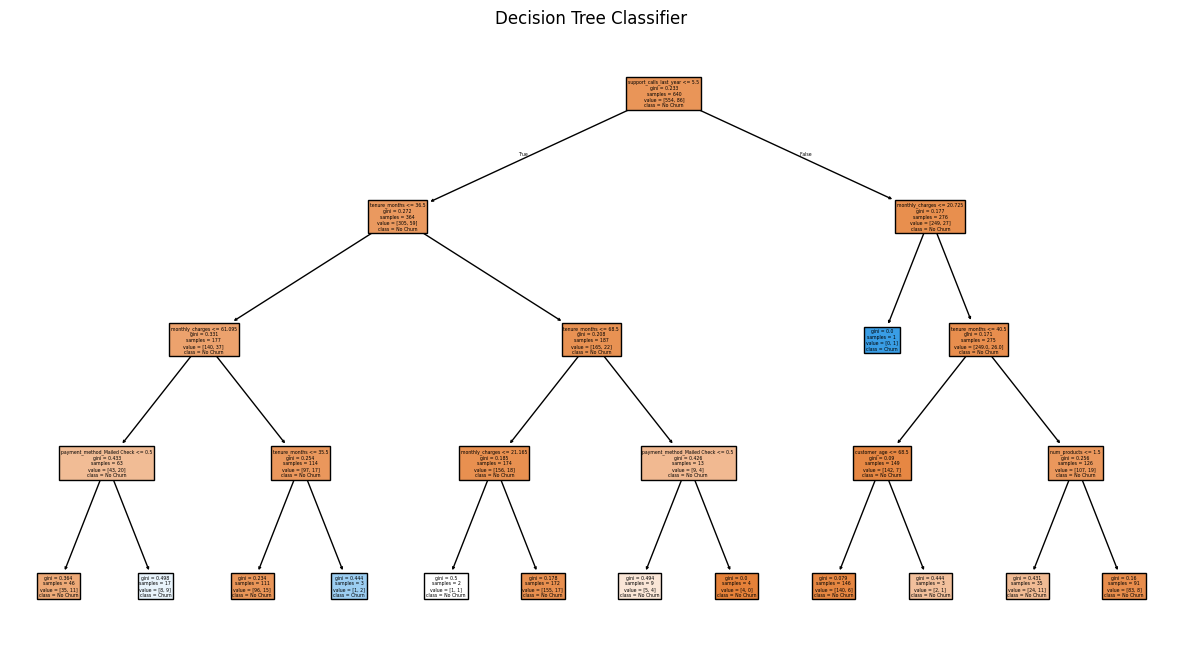

In [162]:
# Training Model
dt_clf = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    random_state=42
)

dt_clf.fit(x_train_churn, y_train_churn)

# Plotting Tree
plt.figure(figsize=(15,8))

plot_tree(
    dt_clf,
    feature_names=x_train_churn.columns,
    class_names=['No Churn', 'Churn'],
    filled=True
)

plt.title("Decision Tree Classifier")

#### **b)** Plot the Decision Tree's feature importances. Compare with Logistic Regression's feature coefficients. Do both models agree on which features matter most?

Text(0.5, 1.0, 'Decision Tree Feature Importance')

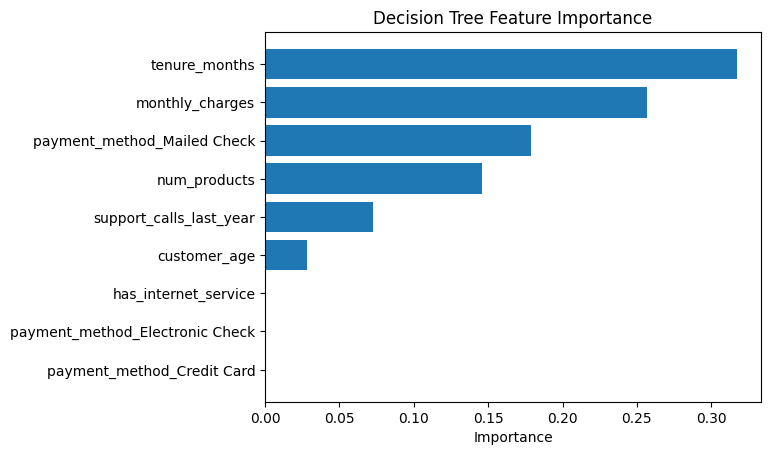

In [163]:
# Getting importances
dt_importance = pd.DataFrame({
    "Feature": x_train_churn.columns,
    "Importance": dt_clf.feature_importances_
}).sort_values(by="Importance", ascending=True)

# Plot
plt.figure()
plt.barh(dt_importance["Feature"], dt_importance["Importance"])

plt.xlabel("Importance")
plt.title("Decision Tree Feature Importance")

Text(0.5, 1.0, 'Logistic Regression Feature Importance')

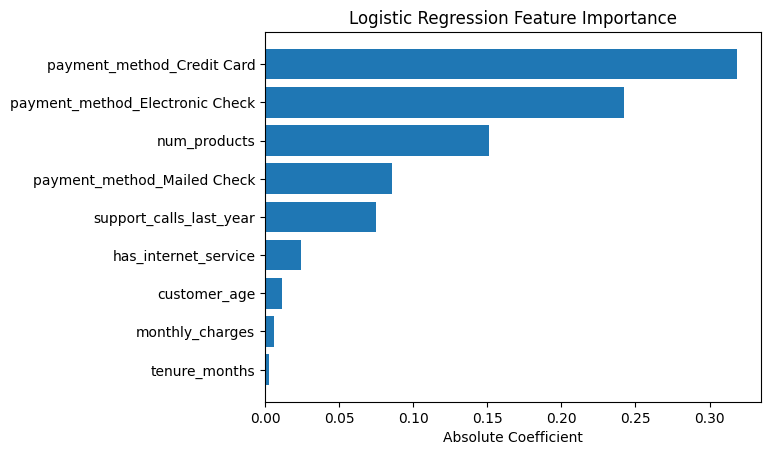

In [164]:
# Logistic Regression Coeff
lr_importance = pd.DataFrame({
    "Feature": x_train_churn.columns,
    "Coefficient": lr_model.coef_[0],
    "Absolute": np.abs(lr_model.coef_[0])
}).sort_values(by="Absolute", ascending=True)

# Plot
plt.figure()
plt.barh(lr_importance["Feature"], lr_importance["Absolute"])

plt.xlabel("Absolute Coefficient")
plt.title("Logistic Regression Feature Importance")

#### **c)** Train a Random Forest Classifier (n_estimators=100). Compare test Accuracy, Precision, Recall, F1 (macro and weighted) with the Decision Tree. Explain why Random Forest reduces variance compared to a single tree.

In [166]:
# Training Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(x_train_churn, y_train_churn)

# -------- 2. Predictions --------
y_pred_rf = rf_clf.predict(x_test_churn)
y_pred_dt = dt_clf.predict(x_test_churn)

In [167]:
# Metrics
def get_metrics(y_true, y_pred):
    return (
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average='macro', zero_division=0),
        recall_score(y_true, y_pred, average='macro', zero_division=0),
        f1_score(y_true, y_pred, average='macro', zero_division=0),
        f1_score(y_true, y_pred, average='weighted', zero_division=0)
    )

In [168]:
# Comparing both models
import pandas as pd

dt_metrics = get_metrics(y_test_churn, y_pred_dt)
rf_metrics = get_metrics(y_test_churn, y_pred_rf)

df_compare = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (macro)", "Recall (macro)", "F1 (macro)", "F1 (weighted)"],
    "Decision Tree": dt_metrics,
    "Random Forest": rf_metrics
})

print(df_compare.round(3))

              Metric  Decision Tree  Random Forest
0           Accuracy          0.825          0.844
1  Precision (macro)          0.423          0.425
2     Recall (macro)          0.485          0.496
3         F1 (macro)          0.452          0.458
4      F1 (weighted)          0.768          0.778


The Random Forest model performs better than the Decision Tree, achieving higher accuracy, precision, recall, and F1-scores. This indicates improved generalization and reduced overfitting

#### **d)** Tune the Random Forest using RandomizedSearchCV with 5-fold Stratified CV over: n_estimators=[50,100,200], max_depth=[3,5,None], min_samples_split=[2,5,10]. Report best parameters and improvement in F1-Score (churn=1).

In [170]:
# Base Model
rf = RandomForestClassifier(random_state=42)

# Parameter Grid
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, None],
    'min_samples_split': [2, 5, 10]
}

# Stratified CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1',
    cv=skf,
    random_state=42,
    n_jobs=-1
)

random_search.fit(x_train_churn, y_train_churn)

# Best Parameters
print("Best Parameters:", random_search.best_params_)

Best Parameters: {'n_estimators': 200, 'min_samples_split': 10, 'max_depth': 3}


In [171]:
# Best model
best_rf = random_search.best_estimator_

# Predictions
y_pred_tuned = best_rf.predict(x_test_churn)

# F1-score (churn=1)
f1_tuned = f1_score(y_test_churn, y_pred_tuned)

# Old RF (before tuning)
f1_old = f1_score(y_test_churn, y_pred_rf)

print("F1 Before Tuning:", f1_old)
print("F1 After Tuning:", f1_tuned)
print("Improvement:", f1_tuned - f1_old)

F1 Before Tuning: 0.0
F1 After Tuning: 0.0
Improvement: 0.0


#### **Q10 a)** Train SVM with kernel='rbf' and class_weight='balanced'. Train K-Nearest Neighbors (KNN) for k = 3, 5, 7, 9, 11. Plot Test Accuracy and F1-Score (churn=1) vs k for KNN. Identify the best k.

In [173]:
# Training SVM
svm_model = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
svm_model.fit(x_train_churn, y_train_churn)

# Predictions
y_pred_svm = svm_model.predict(x_test_churn)

# Metrics
svm_acc = accuracy_score(y_test_churn, y_pred_svm)
svm_f1 = f1_score(y_test_churn, y_pred_svm)

print("SVM Accuracy:", svm_acc)
print("SVM F1 (churn=1):", svm_f1)

SVM Accuracy: 0.43125
SVM F1 (churn=1): 0.24793388429752067


In [174]:
from sklearn.neighbors import KNeighborsClassifier

k_values = [3, 5, 7, 9, 11]

accuracy_list = []
f1_list = []

for k in k_values:
    
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train_churn, y_train_churn)
    
    y_pred_knn = knn.predict(x_test_churn)
    
    acc = accuracy_score(y_test_churn, y_pred_knn)
    f1 = f1_score(y_test_churn, y_pred_knn)
    
    accuracy_list.append(acc)
    f1_list.append(f1)

# Print results
for k, acc, f1 in zip(k_values, accuracy_list, f1_list):
    print(f"k={k} → Accuracy={acc:.3f}, F1={f1:.3f}")

k=3 → Accuracy=0.806, F1=0.114
k=5 → Accuracy=0.838, F1=0.071
k=7 → Accuracy=0.856, F1=0.080
k=9 → Accuracy=0.850, F1=0.077
k=11 → Accuracy=0.856, F1=0.080


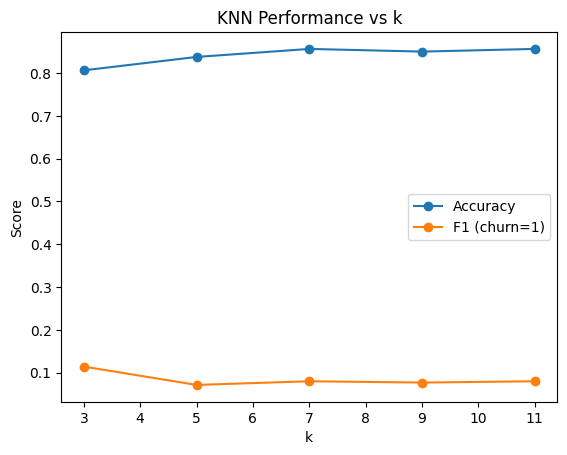

In [175]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(k_values, accuracy_list, marker='o', label='Accuracy')
plt.plot(k_values, f1_list, marker='o', label='F1 (churn=1)')

plt.xlabel("k")
plt.ylabel("Score")
plt.title("KNN Performance vs k")
plt.legend()

In [176]:
# Finding best k
best_index = f1_list.index(max(f1_list))
best_k = k_values[best_index]

print("Best k:", best_k)

Best k: 3


#### **b)** Train a Gaussian Naive Bayes classifier. Explain in code comments: (i) the conditional probability assumption

In [179]:
# Train Model
gnb = GaussianNB()
gnb.fit(x_train_churn, y_train_churn)
y_pred_gnb = gnb.predict(x_test_churn)

# Evaluation
print("Gaussian Naive Bayes Performance:\n")
print(classification_report(y_test_churn, y_pred_gnb))

# (i) Conditional Probability Assumption:
# Naive Bayes assumes that all features are conditionally independent
# given the class label.
#
# Mathematically:
# P(X1, X2, ..., Xn | Y) = P(X1 | Y) * P(X2 | Y) * ... * P(Xn | Y)
#
# This means:
# The model assumes that each feature contributes independently
# to the prediction, even though in real life features may be correlated.
#
# Example:
# In churn prediction, it assumes that 'monthly_charges' and 'tenure'
# affect churn independently, which may not always be true.

Gaussian Naive Bayes Performance:

              precision    recall  f1-score   support

           0       0.85      1.00      0.92       136
           1       0.00      0.00      0.00        24

    accuracy                           0.85       160
   macro avg       0.42      0.50      0.46       160
weighted avg       0.72      0.85      0.78       160



c:\Users\dhruv\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dhruv\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dhruv\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

#### (ii) why NB works well with independent features, and

In [181]:
# Naive Bayes works well with independent features because it assumes that each feature contributes separately to the 
# prediction. This simplifies the computation of probabilities and reduces model complexity, allowing it to perform
# efficiently even with limited data

#### (iii) what happens if features are correlated.

In [182]:
# If features are correlated, Naive Bayes incorrectly assumes them to be independent and may count the same information
# multiple times. This leads to biased probability estimates and can reduce model accuracy.

#### **c)** Create a final classification comparison table: Model | Accuracy | Precision | Recall | F1 (weighted) | AUC-ROC. Include: LR (original), LR+SMOTE, Decision Tree, Random Forest (tuned), SVM, KNN (best k), Naive Bayes. Highlight the best model in a comment.

#### **Q11 a)** Apply GridSearchCV on SVM with param_grid: C=[0.1,1,10], kernel=['linear','rbf'], gamma=['scale','auto']. Use 5-fold StratifiedKFold and scoring='f1'. Report best parameters, best CV F1, and test F1.

#### **b)** Apply RandomizedSearchCV on KNN with: n_neighbors=randint(3,20), weights=['uniform','distance'], metric=['euclidean','manhattan']. Use n_iter=15, cv=5, scoring='f1'. Compare with the Grid Search SVM result.

#### **c)** Plot a heatmap of GridSearchCV scores for SVM (C on x-axis, gamma on y-axis, one heatmap per kernel). Use pivot_table on cv_results_ to extract mean_test_score. Identify the parameter region that performs best.